In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 8.7/8.7 MB 81.0 MB/s  0:00:00
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ------------------ --------------------- 18.1/38.5 MB 89.5 MB/s eta 0:00:01
   -------------------------------------- - 37.5/38.5 MB 92.9 MB/s eta 0:00:01
   ---------------------------------------- 38.5/38.5 MB 78.1 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------

In [7]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [8]:
import pandas as pd
import numpy as np    
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Lectura de datos

In [9]:
df = pd.read_excel('C:\\Users\\FCMN\\Downloads\\Quiz MD\\Datos1D.xlsx')
df.head()

,ingresos,consumo
0,44.617090,9.720475
1,73.430827,12.340257
2,5.010866,1.535624
3,33.721594,7.879812
4,18.941810,4.721109


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ingresos  1000 non-null   float64
 1   consumo   1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ingresos,1000.0,52.557437,27.407560,5.010866,28.933787,53.212577,76.313770,99.745671
consumo,1000.0,9.282316,3.218789,1.419883,7.055647,10.781619,11.838378,12.482348


In [14]:
df.shape

(1000, 2)

Las dimensines que tiene el fichero son 1000 registros y 2 series.

Las variables que contiene son los ingresos y el consumo.

## Modelo polinomial

In [40]:
from sklearn.preprocessing import PolynomialFeatures

# Separamos variables
X = df.iloc[:, 0].values.reshape(-1, 1)  # columna de entrada
y = df.iloc[:, 1].values                 # columna de salida

# Construcción de características polinomiales hasta grado 7
poly = PolynomialFeatures(degree=7, include_bias=True)
X_poly = poly.fit_transform(X)

print("Forma de X_poly:", X_poly.shape)


Forma de X_poly: (1000, 8)


In [39]:
print("Matriz x:", X_poly)
print("--------------------------------------------------------------")
print("Ejemplo de fila:", X_poly[0])

Matriz x: [[1.00000000e+00 4.46170904e+01 1.99068476e+03 ... 1.76809758e+08
  7.88873695e+09 3.51972490e+11]
 [1.00000000e+00 7.34308269e+01 5.39208634e+03 ... 2.13497156e+09
  1.56772727e+11 1.15119510e+13]
 [1.00000000e+00 5.01086561e+00 2.51087741e+01 ... 3.15910292e+03
  1.58298402e+04 7.93212017e+04]
 ...
 [1.00000000e+00 6.85356776e+01 4.69713910e+03 ... 1.51211058e+09
  1.03633523e+11 7.10259375e+12]
 [1.00000000e+00 3.59668847e+01 1.29361679e+03 ... 6.01885822e+07
  2.16479580e+09 7.78609608e+10]
 [1.00000000e+00 7.85753403e+01 6.17408410e+03 ... 2.99523810e+09
  2.35351853e+11 1.84928520e+13]]
--------------------------------------------------------------
Ejemplo de fila: [1.00000000e+00 4.46170904e+01 1.99068476e+03 8.88185620e+04
 3.96282581e+06 1.76809758e+08 7.88873695e+09 3.51972490e+11]


## Ecuación normal

In [18]:
# Tomamos solo los primeros 10 datos para entrenamiento
X_train = X_poly[:10]
y_train = y[:10]

# Ecuación normal sin regularización (λ=0)
w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
print("Coeficientes w*:", w)


Coeficientes w*: [-3.08029387e+00  1.70154086e+00 -2.22243033e-01  1.60429436e-02
 -6.09940122e-04  1.24712477e-05 -1.29448014e-07  5.33238945e-10]


In [19]:
def costo(X, y, w):
    y_pred = X @ w
    return np.mean((y_pred - y) ** 2)

cost_train = []
cost_test = []

X_test = X_poly[10:]
y_test = y[10:]

for r in range(1, 8):
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X[:10])
    X_test_r = poly_r.fit_transform(X[10:])
    
    w_r = np.linalg.inv(X_train_r.T @ X_train_r) @ X_train_r.T @ y[:10]
    
    cost_train.append(costo(X_train_r, y[:10], w_r))
    cost_test.append(costo(X_test_r, y[10:], w_r))


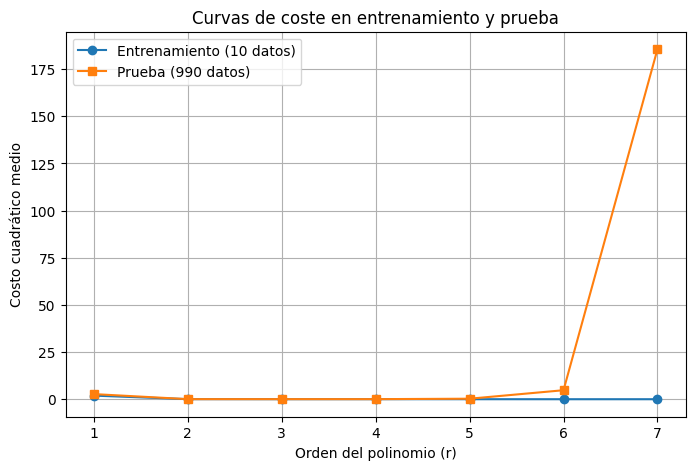

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# Dividimos datos: 10 train, 990 test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=10, shuffle=True, random_state=42)

def costo(X, y, w):
    y_pred = X @ w
    return np.mean((y_pred - y) ** 2)

cost_train = []
cost_test = []

for r in range(1, 8):
    # Construcción de características polinomiales
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_test_r = poly_r.transform(X_test)
    
    # Ecuación normal (sin regularización)
    w_r = np.linalg.inv(X_train_r.T @ X_train_r) @ X_train_r.T @ y_train
    
    # Cálculo de costos
    cost_train.append(costo(X_train_r, y_train, w_r))
    cost_test.append(costo(X_test_r, y_test, w_r))

# Graficamos
plt.figure(figsize=(8,5))
plt.plot(range(1, 8), cost_train, marker="o", label="Entrenamiento (10 datos)")
plt.plot(range(1, 8), cost_test, marker="s", label="Prueba (990 datos)")
plt.xlabel("Orden del polinomio (r)")
plt.ylabel("Costo cuadrático medio")
plt.title("Curvas de coste en entrenamiento y prueba")
plt.legend()
plt.grid(True)
plt.show()



In [24]:
from sklearn.linear_model import    

# Dividimos en train, val, test
X_train, y_train = X[:10], y[:10]
X_val, y_val = X[10:500], y[10:500]
X_test, y_test = X[500:], y[500:]

lambdas = np.logspace(-4, 4, 20)
best_r, best_lambda, best_cost = None, None, float("inf")

for r in range(1, 8):
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_val_r = poly_r.transform(X_val)
    
    for l in lambdas:
        ridge = Ridge(alpha=l, fit_intercept=False)  # regularización de Tikhonov
        ridge.fit(X_train_r, y_train)
        y_val_pred = ridge.predict(X_val_r)
        cost_val = np.mean((y_val - y_val_pred) ** 2)
        
        if cost_val < best_cost:
            best_cost = cost_val
            best_r = r
            best_lambda = l

print("Mejor combinación: r =", best_r, "λ =", best_lambda, "con costo =", best_cost)


Mejor combinación: r = 3 λ = 11.288378916846883 con costo = 0.037263916461169375


C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.68566e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.71301e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.78511e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Pyth

C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.20305e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.20378e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.2057e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Pytho

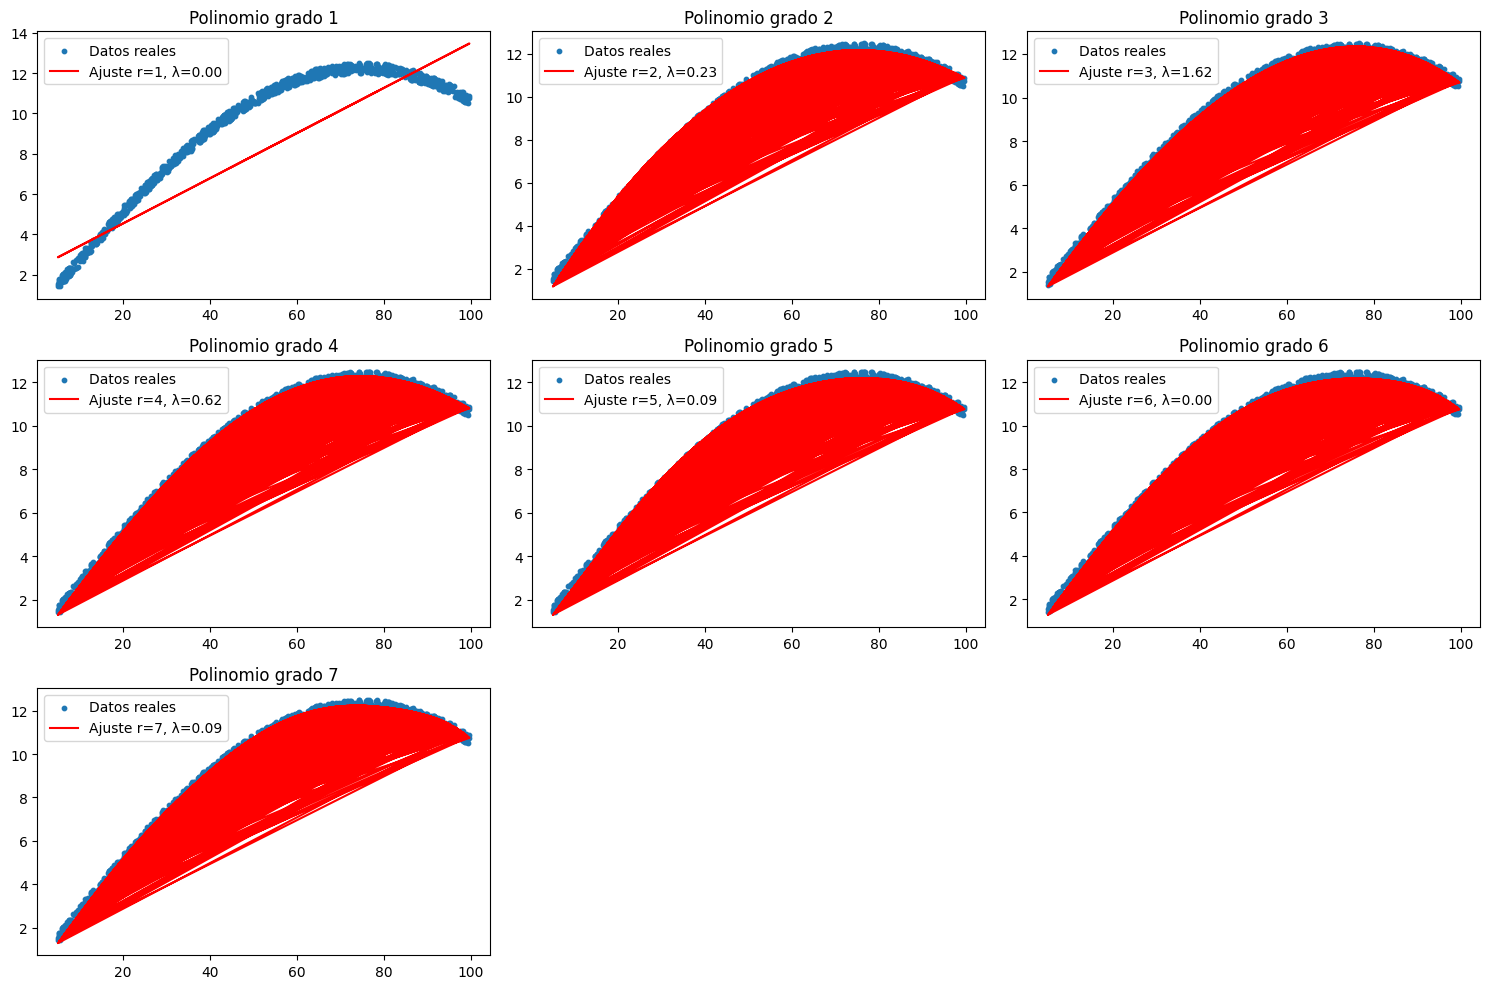

In [31]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

lambdas = np.logspace(-4, 4, 20)

# Gráficas de ajustes
plt.figure(figsize=(15, 10))

for r in range(1, 8):
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_val_r = poly_r.transform(X_val)
    X_test_r = poly_r.transform(X_test)

    best_lambda, best_cost, best_model = None, float("inf"), None
    
    for l in lambdas:
        ridge = Ridge(alpha=l, fit_intercept=False)
        ridge.fit(X_train_r, y_train)
        y_val_pred = ridge.predict(X_val_r)
        cost_val = np.mean((y_val - y_val_pred) ** 2)

        if cost_val < best_cost:
            best_cost = cost_val
            best_lambda = l
            best_model = ridge
    
    # Graficamos con el mejor lambda encontrado
    X_all = poly_r.transform(X)
    y_pred_all = best_model.predict(X_all)

    plt.subplot(3, 3, r)
    plt.scatter(X, y, s=10, label="Datos reales")
    plt.plot(X, y_pred_all, color="red", label=f"Ajuste r={r}, λ={best_lambda:.2f}")
    plt.title(f"Polinomio grado {r}")
    plt.legend()

plt.tight_layout()
plt.show()


In [34]:
from sklearn.linear_model import Ridge

# Nueva división: 10 train, 490 val, 500 test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=10, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=490, shuffle=False)

lambdas = np.logspace(-4, 4, 20)
best_r, best_lambda, best_cost, best_model, best_poly = None, None, float("inf"), None, None

for r in range(1, 8):
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_val_r = poly_r.transform(X_val)
    
    for l in lambdas:
        ridge = Ridge(alpha=l, fit_intercept=False)
        ridge.fit(X_train_r, y_train)
        y_val_pred = ridge.predict(X_val_r)
        cost_val = np.mean((y_val - y_val_pred) ** 2)
        
        if cost_val < best_cost:
            best_cost = cost_val
            best_r = r
            best_lambda = l
            best_model = ridge
            best_poly = poly_r

print("Mejor combinación encontrada:")
print(f" - Grado polinomial r = {best_r}")
print(f" - λ = {best_lambda}")
print(f" - Costo en validación = {best_cost}")


Mejor combinación encontrada:
 - Grado polinomial r = 3
 - λ = 11.288378916846883
 - Costo en validación = 0.037263916461169375


C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.68566e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.71301e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.78511e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Pyth

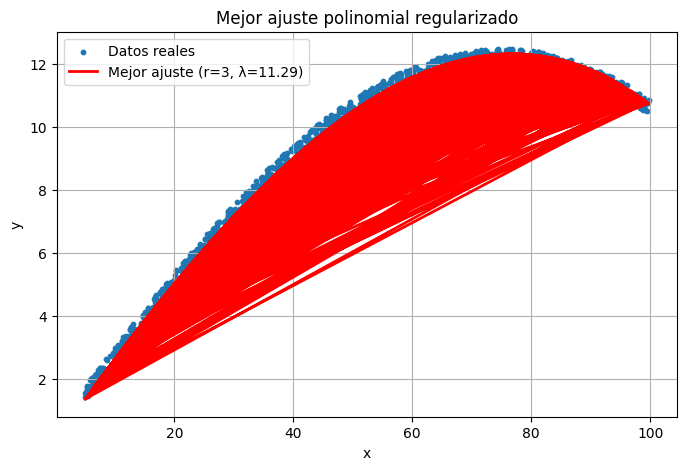

In [35]:
# Generamos predicciones sobre todos los datos con el mejor modelo
X_all_poly = best_poly.transform(X)
y_pred_all = best_model.predict(X_all_poly)

plt.figure(figsize=(8,5))
plt.scatter(X, y, s=10, label="Datos reales")
plt.plot(X, y_pred_all, color="red", linewidth=2,
         label=f"Mejor ajuste (r={best_r}, λ={best_lambda:.2f})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mejor ajuste polinomial regularizado")
plt.legend()
plt.grid(True)
plt.show()


Mejor combinación encontrada:
 - Grado polinomial r = 3
 - λ = 11.288378916846883
 - Costo en validación = 0.037263916461169375


C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.68566e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.71301e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.78511e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Pyth

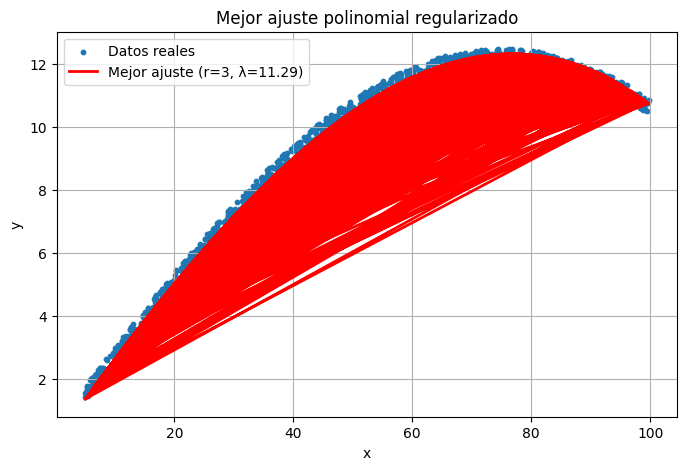

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# División de datos: 10 train, 490 val, 500 test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=10, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=490, shuffle=False)

lambdas = np.logspace(-4, 4, 20)
best_r, best_lambda, best_cost, best_model, best_poly = None, None, float("inf"), None, None

# Búsqueda de mejor (r, λ)
for r in range(1, 8):  
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_val_r = poly_r.transform(X_val)
    
    for l in lambdas:
        ridge = Ridge(alpha=l, fit_intercept=False)
        ridge.fit(X_train_r, y_train)
        y_val_pred = ridge.predict(X_val_r)
        cost_val = np.mean((y_val - y_val_pred) ** 2)
        
        if cost_val < best_cost:
            best_cost = cost_val
            best_r = r
            best_lambda = l
            best_model = ridge
            best_poly = poly_r

print("Mejor combinación encontrada:")
print(f" - Grado polinomial r = {best_r}")
print(f" - λ = {best_lambda}")
print(f" - Costo en validación = {best_cost}")

# Gráfica con el mejor modelo
X_all_poly = best_poly.transform(X)
y_pred_all = best_model.predict(X_all_poly)

plt.figure(figsize=(8,5))
plt.scatter(X, y, s=10, label="Datos reales")
plt.plot(X, y_pred_all, color="red", linewidth=2,
         label=f"Mejor ajuste (r={best_r}, λ={best_lambda:.2f})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mejor ajuste polinomial regularizado")
plt.legend()
plt.grid(True)
plt.show()


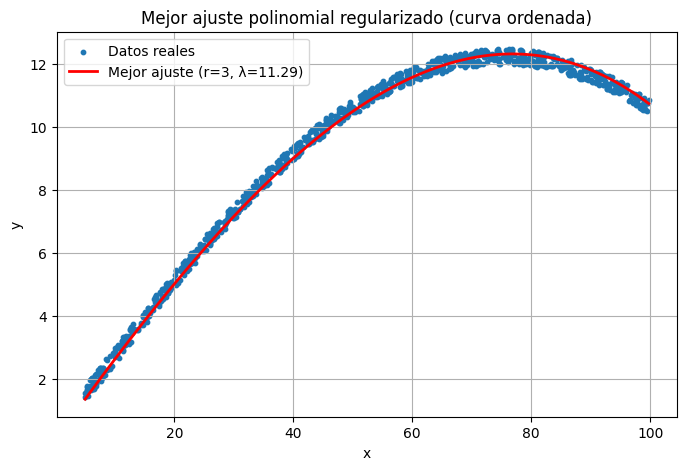

In [37]:
# Ordenamos los datos para graficar suavemente
X_sorted = np.sort(X, axis=0)
X_sorted_poly = best_poly.transform(X_sorted)
y_sorted_pred = best_model.predict(X_sorted_poly)

plt.figure(figsize=(8,5))
plt.scatter(X, y, s=10, label="Datos reales")
plt.plot(X_sorted, y_sorted_pred, color="red", linewidth=2,
         label=f"Mejor ajuste (r={best_r}, λ={best_lambda:.2f})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mejor ajuste polinomial regularizado (curva ordenada)")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.68566e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.71301e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.78511e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\FCMN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Pyth

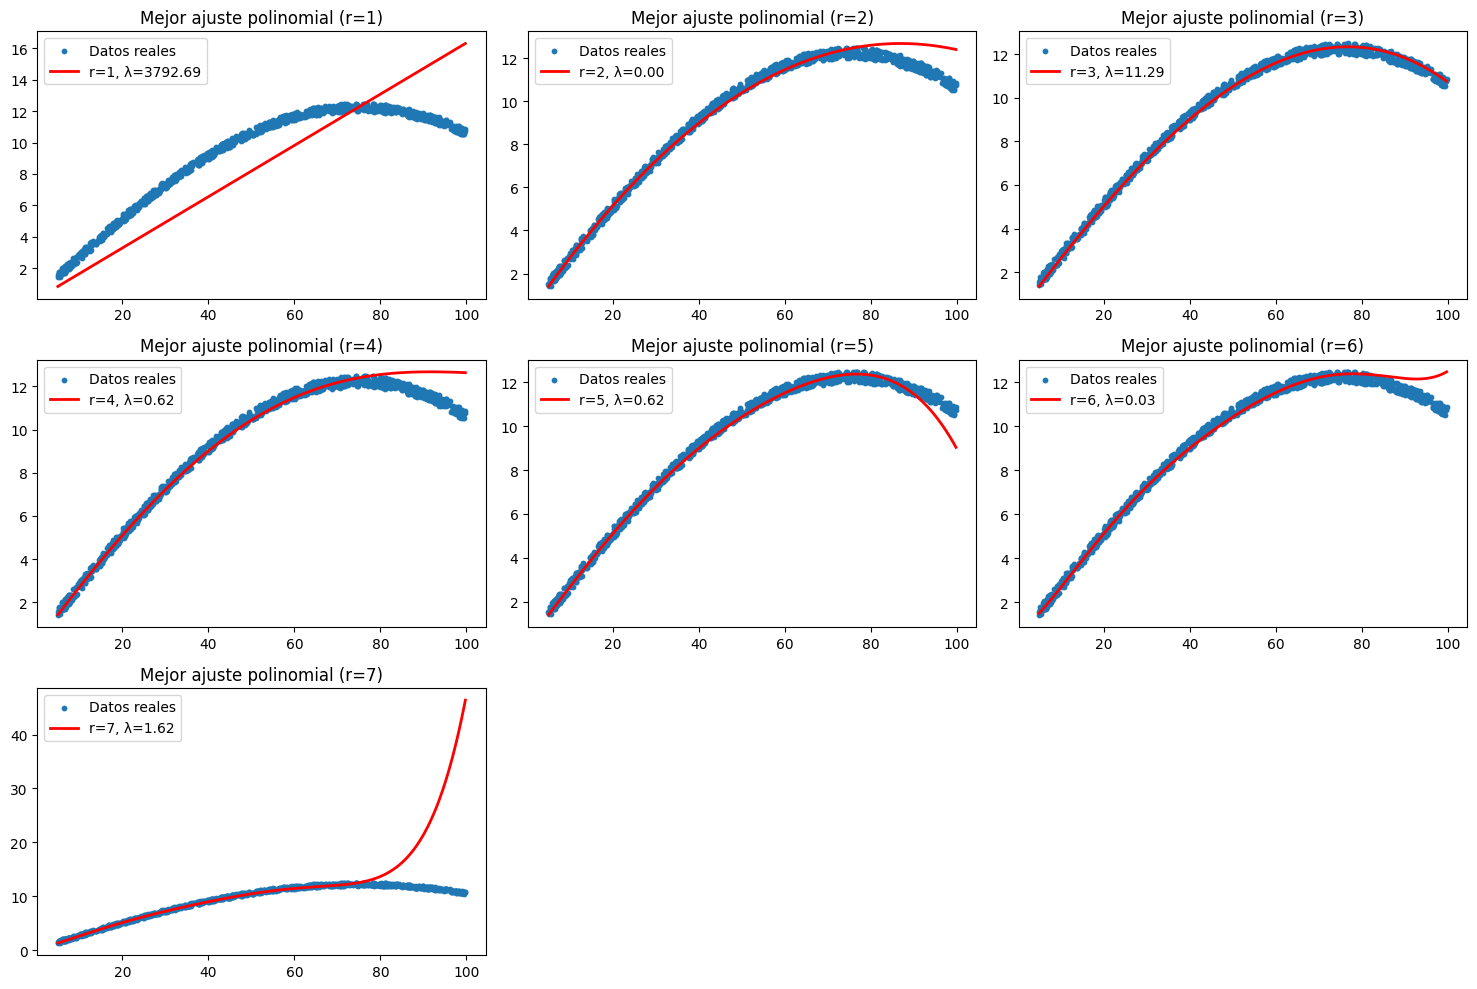

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# División de datos: 10 train, 490 val, 500 test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=10, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=490, shuffle=False)

lambdas = np.logspace(-4, 4, 20)

# Guardamos el mejor modelo de cada r
best_models = {}

for r in range(1, 8):
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_val_r = poly_r.transform(X_val)
    
    best_lambda, best_cost, best_model = None, float("inf"), None
    
    for l in lambdas:
        ridge = Ridge(alpha=l, fit_intercept=False)
        ridge.fit(X_train_r, y_train)
        y_val_pred = ridge.predict(X_val_r)
        cost_val = np.mean((y_val - y_val_pred) ** 2)
        
        if cost_val < best_cost:
            best_cost = cost_val
            best_lambda = l
            best_model = ridge
    
    # Guardamos lo mejor encontrado para este r
    best_models[r] = (best_lambda, best_cost, best_model, poly_r)

# 🔹 Graficamos cada mejor ajuste
plt.figure(figsize=(15, 10))

X_sorted = np.sort(X, axis=0)

for i, r in enumerate(range(1, 8), 1):
    best_lambda, best_cost, best_model, best_poly = best_models[r]
    
    # Predicciones ordenadas
    X_sorted_poly = best_poly.transform(X_sorted)
    y_sorted_pred = best_model.predict(X_sorted_poly)
    
    plt.subplot(3, 3, i)
    plt.scatter(X, y, s=10, label="Datos reales")
    plt.plot(X_sorted, y_sorted_pred, color="red", linewidth=2,
             label=f"r={r}, λ={best_lambda:.2f}")
    plt.title(f"Mejor ajuste polinomial (r={r})")
    plt.legend()

plt.tight_layout()
plt.show()
